In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a): Equation of Motion**

Forces acting on the sphere:
1. **Force of drag:** $F_d = 6 \pi \eta rv$ in the upward direction.
2. **Force of gravity:** $F_g = \frac{4}{3} \pi r^3 \rho_sg$ in the downward direction.
3. **Force of buoyancy:** $F_b = \frac{4}{3} \pi r^3 \rho_fg$ in the upward direction.

Let the downward acceleration of the sphere while falling be $a = \frac{dv}{dt}$. Equation of motion:

$$F_g - F_b - F_d = ma \\[10 pt]
\implies \frac{4}{3} \pi r^3 \rho_sg - \frac{4}{3} \pi r^3 \rho_fg - 6 \pi \eta rv = \frac{4}{3} \pi r^3 \rho_s \frac{dv}{dt} \\[10 pt]
\implies \frac{dv}{dt} = \frac{1}{\rho_s} \left[g(\rho_s - \rho_f) - \frac{9 \eta v}{2r^2} \right] \\[10 pt]
= \frac{9 \eta}{2 r^2 \rho_s} \left[\frac{2r^2 g}{9 \eta} (\rho_s - \rho_f) - v \right] = \frac{v_T - v}{\tau}$$

From the above equation:
$$v_T = \frac{2 r^2 g}{9 \eta} (\rho_s - \rho_f) \\[10 pt]
\tau = \frac{2r^2\rho_s}{9 \eta}$$

In [3]:
# Parameters
r = 1.5 * 1e-3
rho_s = 7800
rho_f = 1260
eta = 1.49
g = 9.81

# Calculation
vT = 2*r**2*g*(rho_s - rho_f)/(9*eta)
tau = 2*r**2*rho_s/(9*eta)

print(f"v_T = {vT: 0.3f} m/s")
print(f"Tau = {tau: 0.3f} s")

v_T =  0.022 m/s
Tau =  0.003 s


## **Part (b): Analytical Solution**

**Part (i):**

$$\frac{dv}{dt} = \frac{v_T - v}{\tau} \\[10 pt]
\implies \int_0^v \frac{dv}{v_T - v} = \int_0^t \frac{dt}{\tau} \\[10 pt]
\implies ln\left(\frac{v_T - v}{v_T} \right) = -\frac{t}{\tau} \\[10 pt]
\implies v = v_T\,(1 - e^{-\frac{t}{\tau}})$$

**Part (ii):**

At $v = 0.99 \, v_T$:

$$0.99 \,v_T = v_T\,(1 - e^{-\frac{t}{\tau}}) \\[10 pt]
\implies e^{-\frac{t}{\tau}} = \frac{1}{100} \\[10 pt]
\implies t^* = \tau \, ln \, 100$$

In [4]:
t_star = tau * np.log(100)
t_star

0.012053801157955407

**Part (iii):**

$$\frac{dx}{dt} = v_T\,(1 - e^{-\frac{t}{\tau}}) \\[10 pt]
\implies x = v_T \, [t - \tau(1 - e^{-\frac{t}{\tau}})]$$

In [22]:
# x(t)
def x(t):
    return vT*(t - tau*(1 - np.exp(-t/tau)))
# v(t)
def v(t):
    return vT*(1 - np.exp(-t/tau))

x(t_star)

0.0002037218338797798

## **Part (c): Numerical Solution**

**Part (i):**

In [19]:
# RK4
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# RK4 caller
def caller(fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(fn, x, y, h)
    return ys

# dv/dt
def f1(t, v):
    return (vT - v)/tau

In [25]:
# Parameters for RK4
ti, tf = 0, 10
dt = 1e-3
N = int((tf - ti)/dt) + 1
ts = np.linspace(ti, tf, N)
v0 = np.array([0])

# Implementing RK4
vs = caller(f1, v0, N, ts, dt)
# Analytical solution
vs_ana =  v(ts)

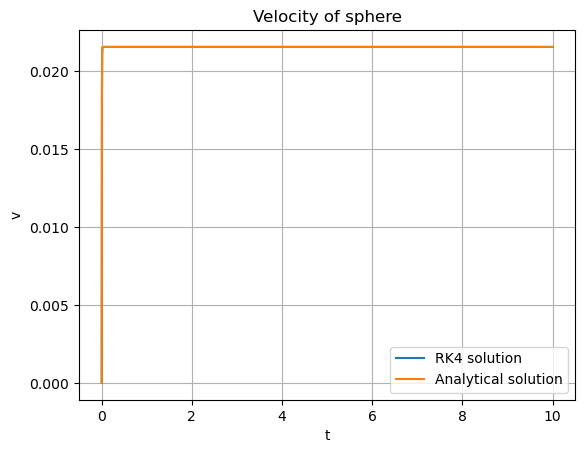

In [28]:
# Plotting
plt.plot(ts, vs, label = "RK4 solution")
plt.plot(ts, vs_ana, label = "Analytical solution")

plt.xlabel("t")
plt.ylabel("v")
plt.title("Velocity of sphere")

plt.legend()
plt.grid()
plt.show()

Both the analytical and numerical solutions overlap with each other, showing close agreement. The sphere attains a constant velocity when $t >> \tau$. Since $\tau \approx 0.003 s$, t quickly becomes larger than $\tau$ and the sphere attains constant velocity.

**Part (ii):**

Plotting the given function

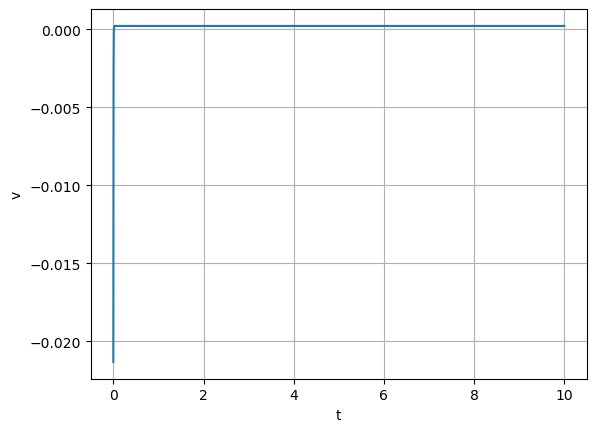

In [ ]:
plt.plot(ts, vs_ana - 0.99*vT)
plt.xlabel("t")
plt.ylabel("v")

plt.grid()
plt.show()

In [ ]:
# Interpolation
from scipy.interpolate import interp1d
v_req = interp1d(ts, vs_ana - 0.99*vT)

In [35]:
# Bisection function
def bisection(f, left: float, right: float, eps: float, maxiter: int = 100):
  # Bad Interval
  if f(left)*f(right) > 0:
    print("Bad Interval")
    return None

  # If the roots are at the interval ends
  if abs(f(left)) < eps:
    return (left, 0)
  if abs(f(right)) < eps:
    return (right, 0)

  mid = (left + right)/2
  iter = 0
  # Loops runs until the function value is within threshold or maxiterations are not reached
  while abs(f(mid)) > eps and iter < maxiter:
    iter += 1
    # print(iter, f(mid))     # To print iteration and function value after each iteration

    if f(left)*f(mid) < 0:    # Root in between left and mid
      right = mid
    else:                     # Root in between mid and right
      left = mid

    mid = (left + right)/2

  # If maximum number of iterations are reached and root is not found
  if iter == maxiter and abs(f(mid)) > eps:
    print("Did not converge")
    return None

  # Else return root
  return (mid, iter)

tl, tr = 0, 0.25
eps = 1e-4
maxiter = 100
t_num, iter = bisection(v_req, tl, tr, eps, maxiter)
t_num

0.01171875

$t^*_{num}$ through analytical method = $t^*$ = 0.012 s

$t^*_{num}$ through numerical method = 0.0117 s

% Error = 2.5 %

In [37]:
(0.012-0.0117)/0.012*100

2.4999999999999996

**Part (iii):**

In [44]:
# Trapezoidal Method
def trapezoidal(ts, ti, tf, h, eps, vs):
  """
  Parameters:
	ts: Time-grid
	ti: Initial time
	tf: Final time
	h: Time step
	eps: Tolerance within which indices of ti and tf can be found within ts
	vs: RK4 Velocity array
  
  Returns:
	float: Area under the velocity profile between initial and final times
  """
  s, e = np.where(abs(ts - ti) < eps)[0][0], np.where(abs(ts - tf) < eps)[0][0]
  vs = vs[s:e+1]
  s = (h/2)*(vs[0] + vs[-1] + 2*sum(vs[1:-1]))
  return s

ti, tf = 0, t_num
eps = 1e-3
x_num = trapezoidal(ts, ti, tf, dt, eps, vs)
x_num

array([0.00018063])

$x^*$ from anaytical solution = $x(t^*)$ = 0.0002 m

$x^*$ from anaytical solution = 0.00018 m

% Error = 10 %

In [45]:
(0.0002 - 0.00018)/0.0002*100

10.0